https://github.com/hwantajee
## 식용버섯 (가우시안, 로지스틱 회귀, 의사결정나무, 랜덤포래스트)

In [4]:
import urllib.request as req
# url = "http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
# req.urlretrieve(url, "mushroom.csv")
# print("다운로드 완료")

다운로드 완료


In [8]:
import pandas as pd

In [12]:
mushroom = pd.read_csv("mushroom.csv", header=None)
# print(mushroom.iloc[:5, :])

  0  1  2  3  4  5  6  7  8  9   ... 13 14 15 16 17 18 19 20 21 22
0  p  x  s  n  t  p  f  c  n  k  ...  s  w  w  p  w  o  p  k  s  u
1  e  x  s  y  t  a  f  c  b  k  ...  s  w  w  p  w  o  p  n  n  g
2  e  b  s  w  t  l  f  c  b  n  ...  s  w  w  p  w  o  p  n  n  m
3  p  x  y  w  t  p  f  c  n  n  ...  s  w  w  p  w  o  p  k  s  u
4  e  x  s  g  f  n  f  w  b  k  ...  s  w  w  p  w  o  e  n  a  g

[5 rows x 23 columns]


In [13]:
data = []
label = []
for index, row in mushroom.iterrows():
    label.append(row.loc[0])
    row_data = []
    for value in row.loc[1:]:
        row_data.append(ord(value))
    data.append(row_data)
print(type(data))

<class 'list'>


In [14]:
import numpy as np

In [15]:
data = np.array(data)
label = np.array(label)

print(data.shape)      
print(label.shape)    
print(data[:5, :])

(8124, 22)
(8124,)
[[120 115 110 116 112 102  99 110 107 101 101 115 115 119 119 112 119 111
  112 107 115 117]
 [120 115 121 116  97 102  99  98 107 101  99 115 115 119 119 112 119 111
  112 110 110 103]
 [ 98 115 119 116 108 102  99  98 110 101  99 115 115 119 119 112 119 111
  112 110 110 109]
 [120 121 119 116 112 102  99 110 110 101 101 115 115 119 119 112 119 111
  112 107 115 117]
 [120 115 103 102 110 102 119  98 107 116 101 115 115 119 119 112 119 111
  101 110  97 103]]


In [17]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_label, test_label = train_test_split(data, label, test_size=0.3, random_state=1)

### Gaussian

In [18]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
model = nb.fit(train_data, train_label)

print(model.score(train_data, train_label))     
print(model.score(test_data, test_label))      

0.8978192050650721
0.8929450369155045


### Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
model = lr.fit(train_data, train_label)

print(model.score(train_data, train_label))      
print(model.score(test_data, test_label)) 

0.9428420682377769
0.9397046759639048


/opt/homebrew/Cellar/jupyterlab/3.3.2/libexec/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
model = dt.fit(train_data, train_label)

print(model.score(train_data, train_label))     
print(model.score(test_data, test_label))        

1.0
1.0


### Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10, random_state=1)
model = rf.fit(train_data, train_label)

print(model.score(train_data, train_label))     
print(model.score(test_data, test_label))  

1.0
1.0


### 시각화

In [25]:
from sklearn.metrics import confusion_matrix

predicts = model.predict(test_data)
cm = confusion_matrix(test_label, predicts)

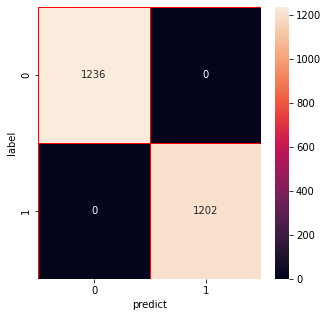

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)

plt.xlabel("predict")
plt.ylabel("label")
plt.show()

In [27]:
from sklearn.metrics import accuracy_score, classification_report

score = accuracy_score(test_label, predicts)
print(score)                                                

scores = classification_report(test_label, predicts)
print(score)     

1.0
1.0
